# 🫀 Day 05 — 선형 분류 · 분류 평가지표 · 다중 분류

정답이 **카테고리**인 문제(분류)를 제대로 다루는 하루.
모델을 만드는 것보다 **"이 모델이 정말 쓸 만한가"를 판단하는 방법**에 무게가 실린다.

> ⚙️ **아래 코드는 수업 때 작성한 내용 그대로이며, 이해를 돕는 주석과 설명만 추가했습니다.**
> (`day05_1.ipynb` + `day05.ipynb` 를 하나로 합친 파일입니다.)

**진행 순서**

**🩺 Part 1 · 심장질환 데이터 이진 분류 (`heart.csv`)**
1. 데이터 불러오기 & 전처리 (결측치 · 이상치 확인)
2. EDA — 타깃 분포와 연령대별 발병률
3. 가설 1 — 흉통 유형(cp)에 따른 발병률
4. 가설 2 — 운동 중 최대 심박수(thalach)에 따른 발병률
5. 인코딩(Label · One-Hot) & 데이터 분리
6. Logistic Regression + 교차검증(Cross Validation)
7. SVM (LinearSVC)
8. 분류 평가지표 — precision · recall · f1
9. **임계값(Threshold) 조정** — 재현율과 정밀도의 맞교환
10. ROC Curve & AUC

**🔢 Part 2 · 손글씨 숫자 다중 분류 (`load_digits`)**
11. 데이터 준비 & 확인
12. 이진 분류기로 다중 분류하기 — OvR vs OvO
13. Confusion Matrix — 어떤 숫자끼리 헷갈리는가
14. 클래스별 성능 & macro · micro · weighted 평균
15. 오답 데이터 직접 확인

**분류 평가지표 한눈에**

| 지표 | 계산 | 의미 | 언제 중요한가 |
|---|---|---|---|
| Accuracy (정확도) | (TP+TN) / 전체 | 전체 중 맞힌 비율 | 클래스가 **균형**일 때만 믿을 만하다 |
| Recall (재현율) | TP / (TP+FN) | 실제 양성 중 **찾아낸** 비율 | 놓치면 큰일 → **암·심장질환 진단**, 금융사기 |
| Precision (정밀도) | TP / (TP+FP) | 양성이라 예측한 것 중 **진짜** 비율 | 잘못 잡으면 큰일 → 스팸 메일 분류 |
| F1-score | 두 지표의 조화평균 | Precision·Recall 의 균형 | 둘 다 챙기고 싶을 때 |

---
# 🩺 Part 1 · 심장질환 데이터 이진 분류 (`heart.csv`)

환자의 검사 수치로 **심장질환이 있는지(`target` = 1) 없는지(0)** 를 맞히는 **이진 분류** 문제.

> 💡 이 문제는 **놓치는 것(FN)이 가장 위험하다.**
> 환자를 정상이라고 판단하면 치료 기회를 잃기 때문 → **Recall(재현율)이 중요한 문제**다.

## 1. 데이터 불러오기 & 전처리

먼저 데이터의 **모양(shape) · 자료형(dtype) · 결측치 · 이상치**를 순서대로 확인한다.

| 컬럼 | 의미 | 컬럼 | 의미 |
|---|---|---|---|
| `age` | 나이 | `exang` | 운동 유발 협심증 (1/0) |
| `sex` | 성별 (1=남, 0=여) | `oldpeak` | 운동으로 유발된 ST 하강 |
| `cp` | 흉통(chest pain) 유형 | `slope` | ST 분절의 기울기 |
| `trestbps` | 안정 시 혈압 | `ca` | 주요 혈관 수 (0~3) |
| `chol` | 콜레스테롤 수치 | `thal` | 지중해빈혈 검사 결과 |
| `fbs` | 공복 혈당 > 120 (1/0) | **`target`** | **심장질환 여부 (1=있음) → 정답** |
| `restecg` | 안정 시 심전도 결과 | | |
| `thalach` | 운동 중 최대 심박수 | | |

In [104]:
# 실습에 필요한 기본 라이브러리 불러오기
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns          # 시각화 (matplotlib을 더 쉽게 쓰게 해준다)
import pandas as pd

In [105]:
# 심장질환 데이터 불러오기 → 상위 5개 행만 미리보기
df = pd.read_csv('./data/heart.csv')
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,typical angina,125,212,0,1,168,0,1.0,2,2,reversible defect,0
1,53,1,typical angina,140,203,1,0,155,1,3.1,0,0,reversible defect,0
2,70,1,typical angina,145,174,0,1,125,1,2.6,0,0,reversible defect,0
3,61,1,typical angina,148,203,0,1,161,0,0.0,2,1,reversible defect,0
4,62,0,typical angina,138,294,1,1,106,0,1.9,1,3,fixed defect,0


In [106]:
# data의 형태
df.shape    # (행 개수, 열 개수) = (환자 수, 컬럼 수)

(1025, 14)

In [107]:
# 컬럼별 개수 / 자료형(Dtype) / 결측치 확인
# → cp, thal 이 object(문자형)이므로 나중에 인코딩이 필요하다
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   object 
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1018 non-null   object 
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(11), object(2)
memory usage: 112.2+ KB


In [108]:
# Null  값을 확인
print(df.isnull().sum())    # thal 컬럼에 결측치 7개가 있다

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        7
target      0
dtype: int64


In [109]:
# Null 데이터 삭제
# 전체 1025개 중 7개뿐이라 삭제해도 영향이 적다 (많았다면 채우는 방법을 고민해야 한다)
df.dropna(inplace=True)     # inplace=True : 원본 df를 바로 수정

In [110]:
# Null 값을 확인
print(df.isnull().sum())    # 모두 0 → 결측치 처리 완료

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64


In [111]:
# Outlier 확인
# describe() : 개수·평균·표준편차·최솟값·사분위수·최댓값을 한 번에 보여준다
df.describe()

# 연속형(수치) 변수 기준: IQR/ 표준점수(z>3)로 보면
# chol, trestnps, oldpeak가 경계 밖 데이터 좀 있다.

,age,sex,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,target
count,1018.000000,1018.000000,1018.000000,1018.000000,1018.000000,1018.000000,1018.000000,1018.000000,1018.000000,1018.000000,1018.000000,1018.000000
mean,54.447937,0.696464,131.636542,246.253438,0.146365,0.529470,149.187623,0.334971,1.074951,1.385069,0.759332,0.513752
std,9.101835,0.460011,17.574327,51.676406,0.353646,0.528086,23.006116,0.472212,1.177640,0.618506,1.032432,0.500057
min,29.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.000000,0.000000,120.000000,211.000000,0.000000,0.000000,132.000000,0.000000,0.000000,1.000000,0.000000,0.000000
50%,56.000000,1.000000,130.000000,240.000000,0.000000,1.000000,152.000000,0.000000,0.800000,1.000000,0.000000,1.000000
75%,61.000000,1.000000,140.000000,275.750000,0.000000,1.000000,166.000000,1.000000,1.800000,2.000000,1.000000,1.000000
max,77.000000,1.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,1.000000


## 2. EDA(탐색적 데이터 분석) — 타깃 분포와 연령대

모델을 돌리기 전에 **데이터가 어떻게 생겼는지 먼저 본다.**

> 📌 가장 먼저 볼 것은 **정답(`target`)의 균형**이다.
> 한쪽으로 크게 치우쳐 있으면 정확도(Accuracy)를 믿을 수 없게 된다.

In [112]:
# 정답 클래스의 개수 확인 → 1(질환 있음) 523 : 0(없음) 495 로 거의 균형 잡힌 데이터
df['target'].value_counts()

target
1    523
0    495
Name: count, dtype: int64

<Axes: xlabel='age', ylabel='count'>

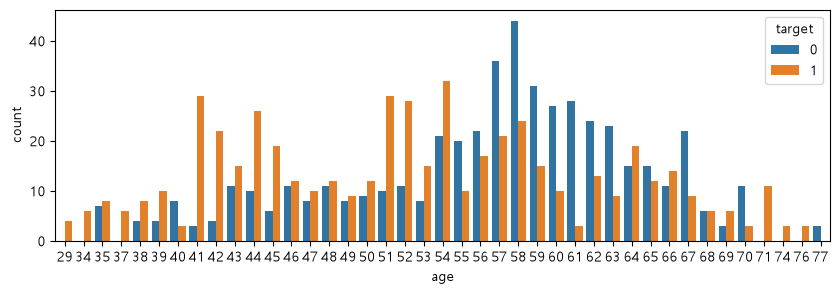

In [113]:
# 나이별로 질환 유무(hue=target)를 나눠서 개수 세기
plt.figure(figsize=(10,3))
sns.countplot(x='age',hue='target',data=df)

In [114]:
# 전체 환자 중 심장질환자의 비율 (약 51%) → 클래스 균형 확인
(df["target"]==1).sum()/len(df["target"])

# <40세 : 조기 발병(early onset) 심장질환, 드물지만 위험도 높다.
# 40-49세: 중년 초반, 위험요인이 서서히 축적된다.
# 50-59세: 중년 후반, 고혈압, 고지혈증, 당뇨가 본격적으로 위험에 기여한다.
# 60-69세: 고령층 진입, 사건 발생률이 빠르게 증가한다.
# >=70세: 고위험군으로 분류, 합병증/다질환 관리가 필요하다.

np.float64(0.5137524557956779)

### 2-1. 나이를 구간으로 묶어서 보기 (`pd.cut`)

나이는 연속형이라 한 살 단위로 보면 패턴이 잘 안 보인다.
→ **연령대(구간)로 묶어서 범주형으로 바꾸면** 그룹별 비교가 쉬워진다.

> `df.groupby('묶을 기준')['볼 값'].mean()` → 그룹별 평균
> `target`은 0/1이므로 **평균 = 발병 비율**이 된다.

In [115]:
bins = [0, 40, 50, 60, 70, 120]                     # 구간 경계값
labels = ['0~40', '41~50', '51~60', '61~70', '>70'] # 각 구간의 이름

# age(연속형)을 구간으로 잘라서 범주형(labels)으로 변환
df['age_gp'] = pd.cut(df['age'], bins = bins, labels = labels, right = True)

# 연령대 별 심장질환(target == 1)의 비율 확인
# target이 0/1이므로 평균값이 곧 '발병 비율'이 된다
age_target = df.groupby('age_gp')['target'].mean()
print(age_target)

age_gp
0~40     0.661765
41~50    0.672065
51~60    0.466357
61~70    0.373016
>70      0.850000
Name: target, dtype: float64


C:\Users\smhrd\AppData\Local\Temp\ipykernel_12196\3441943474.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_target = df.groupby('age_gp')['target'].mean()


In [116]:
# age_gp 컬럼이 잘 만들어졌는지 확인
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target,age_gp
0,52,1,typical angina,125,212,0,1,168,0,1.0,2,2,reversible defect,0,51~60
1,53,1,typical angina,140,203,1,0,155,1,3.1,0,0,reversible defect,0,51~60
2,70,1,typical angina,145,174,0,1,125,1,2.6,0,0,reversible defect,0,61~70
3,61,1,typical angina,148,203,0,1,161,0,0.0,2,1,reversible defect,0,61~70
4,62,0,typical angina,138,294,1,1,106,0,1.9,1,3,fixed defect,0,61~70


In [117]:
#  연령별 심장 질환 발병률

# age_gp 열을 기준으로 그룹화하여 각  그룹에 대한 특정 통계치 계산 한 새로운 df
# agg() : aggregate, 하나 이상의 함수를 적용하여 그룹별로 집계 결과
# count = 그 연령대의 전체 인원, sum = target이 1인(질환 있는) 인원
df_gp = df.groupby('age_gp')['target'].agg(['count', 'sum'])
df_gp

C:\Users\smhrd\AppData\Local\Temp\ipykernel_12196\559048595.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_gp = df.groupby('age_gp')['target'].agg(['count', 'sum'])


,count,sum
age_gp,,
0~40,68,45
41~50,247,166
51~60,431,201
61~70,252,94
>70,20,17


In [118]:
# ratio: 비율
# 비율계산: 각 연령대에서 발병한 비율을 계산해서 ratio에 넣겠다
# 비율 계산 방법: (발병 인원 수 / 전체 인원 수) * 100, 소수점 첫째 자리까지 반올림
df_gp['ratio'] = round((df_gp['sum']/df_gp['count']) * 100, 1)
df_gp
# 장년층에 비해 중년층, 노년층에 심장 질환 방별률이 높다.
# ※ >70 구간은 인원이 20명뿐이라 비율(85%)이 크게 흔들릴 수 있다 → 표본 수도 함께 봐야 한다

,count,sum,ratio
age_gp,,,
0~40,68,45,66.2
41~50,247,166,67.2
51~60,431,201,46.6
61~70,252,94,37.3
>70,20,17,85.0


## 3. 가설 1 — 흉통(cp)이 특정 유형일수록 심장 질환 발병률이 높을 것이다

- cp 변수와 target 변수간의 데이터를 직접 보고 시각화

> **가설 → 집계 → 시각화** 순서로 확인하는 것이 EDA의 기본 흐름이다.

In [119]:
# cp 별 심장 질환 현황 확인
cp_target_gp = df.groupby('cp')['target'].agg(['count', 'sum'])

# 흉통 유형별 발병률(%) 계산
cp_target_gp['ratio'] = round((cp_target_gp['sum'] / cp_target_gp['count'])*100 ,1)
cp_target_gp
# atypical angina(80.2%), non-anginal(76.9%)이 높고 typical angina(24.7%)는 낮다

,count,sum,ratio
cp,,,
asymptomatic,77,51,66.2
atypical angina,167,134,80.2
non-anginal,281,216,76.9
typical angina,493,122,24.7


In [120]:
# matplotlib을 위한 한글 폰트 설정
# (설정하지 않으면 그래프의 한글이 네모(□)로 깨진다)
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False      # 음수 부호(-)가 깨지는 것 방지

C:\Users\smhrd\AppData\Local\Temp\ipykernel_12196\1852107099.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x = cp_target_gp.index, y = cp_target_gp['ratio'], palette = 'viridis')


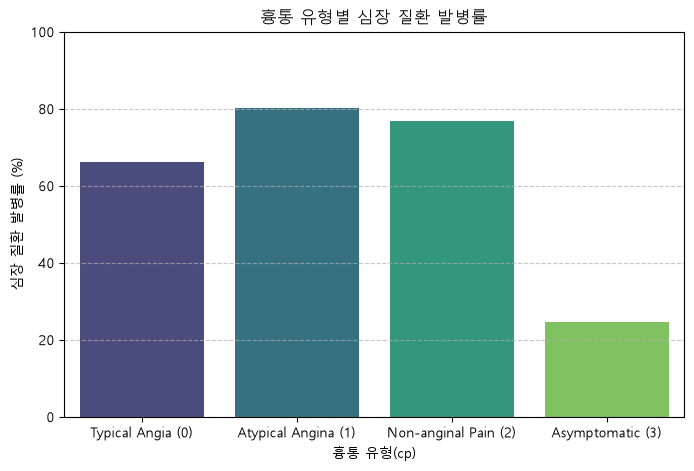

In [121]:
plt.figure(figsize=(8,5))
# x축은 cp, y축은 발병률
sns.barplot(x = cp_target_gp.index, y = cp_target_gp['ratio'], palette = 'viridis')
plt.title('흉통 유형별 심장 질환 발병률')
plt.xlabel('흉통 유형(cp)')
plt.ylabel('심장 질환 발병률 (%)')
# ※ xticks의 라벨은 직접 지정한 것이라, 실제 막대 순서(알파벳순)와 이름이 어긋날 수 있다
plt.xticks(ticks = [0,1,2,3], labels = ['Typical Angia (0)', 'Atypical Angina (1)',
                                       'Non-anginal Pain (2)', 'Asymptomatic (3)'])
plt.ylim(0, 100)                                    # y축을 0~100%로 고정해야 비교가 공정하다
plt.grid(axis='y', linestyle='--', alpha = 0.7)
plt.show()

## 4. 가설 2 — 운동 중 최대 심박수(thalach)가 높을수록 발병률이 낮을 것이다

- thalach 변수의 분포를 살펴보고, 이를 특정 구간으로 나눠서 각 구간별 심장질환 발병률 비교

> 구간을 나눌 땐 **분포 그래프를 먼저 그려보고** 경계값을 정한다.

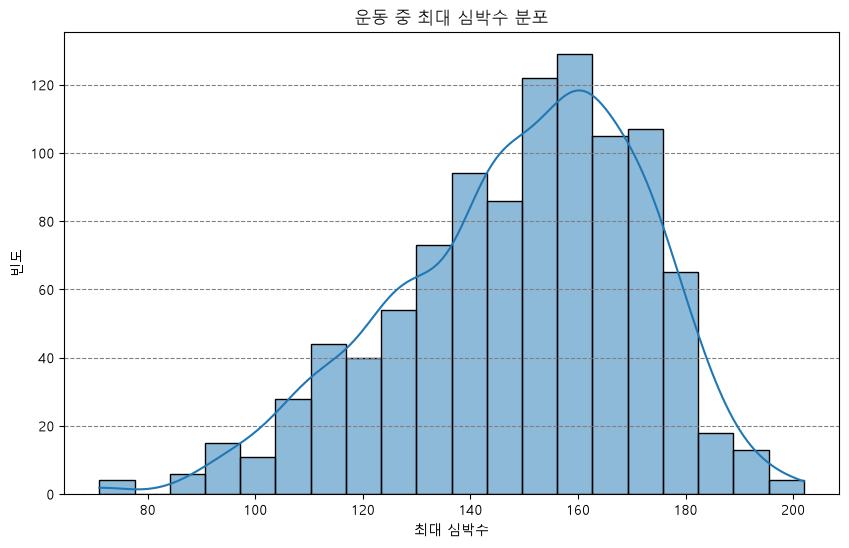

In [122]:
# 최대 심박수의 분포 확인 (kde=True : 부드러운 밀도 곡선도 함께 그린다)
plt.figure(figsize=(10,6))
sns.histplot(df['thalach'], kde=True, bins=20)
plt.title('운동 중 최대 심박수 분포')
plt.xlabel('최대 심박수')
plt.ylabel('빈도')
plt.grid(axis='y', linestyle='--', color='gray')
plt.show()

In [123]:
# 최대 심박수를 범주화 시켜서 심장 질환 발병률을 비교한다.
# 최대 심박수 값을 몇 개의 구간으로 나눌지 → 분포 그래프를 참고해서 적절한 구간 경계를 나누겠다.
# 임의로 3개로 나누어보겠다.
thal_bins = [df['thalach'].min(), 130, 160, df['thalach'].max()] # 구간 경계값
thal_labels = ['<130', '131-160', '>160']

# pd.cut 사용해서 최대 심박수 변수를 범주형으로 변환한다.
# right = True: 구간의 오른쪽 경계값 포함 (]
# include_lowest = True: 첫 구간에서 왼쪽 경계값을 포함한다.
df['thalach_gp'] = pd.cut(df['thalach'], bins = thal_bins, labels = thal_labels, right=True, include_lowest=True)

thal_target_gp = df.groupby('thalach_gp')['target'].agg(['count', 'sum'])
# ⚠️ 오타: ** 는 거듭제곱이라 결과가 전부 0.0으로 나왔다 → (sum/count) * 100 이 맞다
thal_target_gp['ratio'] = round((thal_target_gp['sum']/thal_target_gp['count']) ** 100, 1)

thal_target_gp
# sum/count로 직접 계산해보면 <130 : 21.7% / 131-160 : 46.6% / >160 : 74.9%
# → 심박수가 높을수록 오히려 발병 비율이 높게 나와, 세운 가설과 반대 결과였다

C:\Users\smhrd\AppData\Local\Temp\ipykernel_12196\522429885.py:12: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  thal_target_gp = df.groupby('thalach_gp')['target'].agg(['count', 'sum'])


,count,sum,ratio
thalach_gp,,,
<130,217,47,0.0
131-160,438,204,0.0
>160,363,272,0.0


## 5. Modeling 준비 — 인코딩 & 데이터 분리

머신러닝 모델은 **문자를 이해하지 못한다.** 문자형 컬럼(`cp`, `thal`)을 숫자로 바꿔야 한다.

| 방법 | 설명 | 언제 |
|---|---|---|
| **Label Encoding** | 각 값에 번호를 붙인다 (0,1,2,3) | 순서가 있는 값 (등급 등) |
| **One-Hot Encoding** | 값마다 컬럼을 만들어 0/1 로 표시 | 순서가 없는 값 (혈액형, 색상) |

> ⚠️ 순서가 없는 값에 Label Encoding 을 쓰면 모델이 **"3 > 1 이니까 더 크다"** 라고
> 잘못 해석할 수 있다. 그래서 보통 One-Hot 을 쓴다 (`pd.get_dummies`).

In [124]:
# 파생 컬럼(age_gp, thalach_gp)까지 붙은 현재 상태 확인
df

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target,age_gp,thalach_gp
0,52,1,typical angina,125,212,0,1,168,0,1.0,2,2,reversible defect,0,51~60,>160
1,53,1,typical angina,140,203,1,0,155,1,3.1,0,0,reversible defect,0,51~60,131-160
2,70,1,typical angina,145,174,0,1,125,1,2.6,0,0,reversible defect,0,61~70,<130
3,61,1,typical angina,148,203,0,1,161,0,0.0,2,1,reversible defect,0,61~70,>160
4,62,0,typical angina,138,294,1,1,106,0,1.9,1,3,fixed defect,0,61~70,<130
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1020,59,1,atypical angina,140,221,0,1,164,1,0.0,2,0,fixed defect,1,51~60,>160
1021,60,1,typical angina,125,258,0,0,141,1,2.8,1,1,reversible defect,0,51~60,131-160
1022,47,1,typical angina,110,275,0,0,118,1,1.0,1,1,fixed defect,0,41~50,<130
1023,50,0,typical angina,110,254,0,0,159,0,0.0,2,0,fixed defect,1,41~50,131-160


In [125]:
# 컬럼별 자료형 확인
# ※ 'O'(문자 오)가 아니라 '0'(숫자 영)과 비교해서 전부 False가 나왔다 → 아래 셀에서 'O'로 수정
for i in df.columns:
    print(df[i].dtypes, df[i].dtypes == '0')

int64 False
int64 False
object False
int64 False
int64 False
int64 False
int64 False
int64 False
int64 False
float64 False
int64 False
int64 False
object False
int64 False
category False
category False


In [126]:
# data에서 numeric, categorical value 나눠보겠다.
numeric = []
categorical = []

for i in df.columns:
    if df[i].dtypes == 'O':     # 'O' = object(문자형)
        categorical.append(i)
    else:
        numeric.append(i)

print('categorical: ',categorical)      # cp, thal → 인코딩 대상
print('numeric: ', numeric)

categorical:  ['cp', 'thal']
numeric:  ['age', 'sex', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'target', 'age_gp', 'thalach_gp']


In [127]:
# Emcoding (Label, One-hot)
df['cp'].value_counts()

# 흉통 유형을 직접 만든 딕셔너리로 숫자 변환 (Label Encoding)
CP_dict = {
    'asymptomatic'    : 0,
    'atypical angina' : 1,
    'non-anginal'     : 2,
    'typical angina'  : 3
}

df['cp'] = df['cp'].map(CP_dict)    # map : 딕셔너리 규칙대로 값을 바꿔준다

# 매핑 누락 검증 — 0이 아니면 딕셔너리 키가 틀린 것
print('매핑 실패:', df['cp'].isnull().sum())

매핑 실패: 0


In [128]:
# X(문제) / y(정답) 나누기
# age_gp, thalach_gp는 EDA용으로 만든 파생 컬럼이라 학습에서 제외한다
# (age를 가공한 것이라 그대로 두면 같은 정보가 중복된다)
X = df.drop(['age_gp', 'thalach_gp', 'target'], axis = 1)
y = df['target']

# one-hot encoding
# 남은 문자형 컬럼(thal)이 thal_normal / thal_fixed defect ... 처럼 0/1 컬럼으로 펼쳐진다
X_one_hot = pd.get_dummies(X)

X_one_hot.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal_fixed defect,thal_normal,thal_reversible defect
0,52,1,3,125,212,0,1,168,0,1.0,2,2,False,False,True
1,53,1,3,140,203,1,0,155,1,3.1,0,0,False,False,True
2,70,1,3,145,174,0,1,125,1,2.6,0,0,False,False,True
3,61,1,3,148,203,0,1,161,0,0.0,2,1,False,False,True
4,62,0,3,138,294,1,1,106,0,1.9,1,3,True,False,False


In [129]:
# 데이터 분리
from sklearn.model_selection import train_test_split

# stratify=y : 학습/평가 데이터에 정답(0/1) 비율이 똑같이 유지되도록 나눈다
X_train, X_test, y_train, y_test = train_test_split(X_one_hot, y,
                                                    test_size=0.3,
                                                    random_state=24,
                                                    stratify=y)

## 6. Logistic Regression — 확률로 분류하기

이름에 Regression 이 붙지만 **분류 모델**이다.

1. 선형식으로 **로짓(logit)** 값을 계산하고
2. **Sigmoid 함수**로 그 값을 **0 ~ 1 사이 확률**로 바꾼 뒤
3. **0.5 이상이면 양성(1)** 으로 판정한다.

> 🎯 **교차검증(Cross Validation)**
> 학습 데이터를 다시 여러 겹(fold)으로 나눠 번갈아 검증한다.
> → 한 번의 7:3 분리보다 **운(random_state)에 덜 좌우되는 성능**을 얻을 수 있다.

In [130]:
from sklearn.model_selection import train_test_split

# 데이터 분리
# stratify = y: 정답 클래스의 비율을 7:3으로 맞춰서
X_train, X_test, y_train, y_test = train_test_split(X_one_hot, y, test_size = 0.3, stratify = y, random_state = 24)

from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(max_iter = 10000)
# Hyper Parameter
# penality: L1, L2
# C: alpha와 같은 역할로, 규제 강도의 역수 → 숫자가 커질수록 규제가 약하다
# max_iter: 최대 반복 횟수
### 잘 만들어진 Sigmoid 곡선을 찾기 위해 여러번(max_iter 이하 횟수로) 학습한다.

lr_model.fit(X_train, y_train)

UnicodeDecodeError: 'cp949' codec can't decode byte 0xe2 in position 2950: illegal multibyte sequence

UnicodeDecodeError: 'cp949' codec can't decode byte 0xe2 in position 2950: illegal multibyte sequence

LogisticRegression(max_iter=10000)

In [ ]:
# 교차검증(cross-validation)
# 모델의 일반화 성능을 올리기 위한 학습 방법
# Train Set안에 다시 한번 Train / Valid Set으로 여러겹 나눠 평가
# 평균적인 모델의 성능을 계산하면, 한번 Train, Test (7:3)으로 나눠서 했을때 보다 일반화 된 모델이 나온다.

from sklearn.model_selection import cross_val_score
cross_val_score(lr_model, X_train, y_train, cv=5).mean()    # cv=5 : 5겹으로 나눠 검증 (값을 보려면 print 필요)

lr_model.score(X_test, y_test)      # 마지막 줄만 출력된다 → 평가 데이터 정확도 0.833

0.8333333333333334

## 7. SVM (Support Vector Machine)

두 클래스 사이의 **경계선(결정 경계)** 을 긋되, **여백(margin)이 가장 넓어지도록** 긋는 모델.
경계선을 정하는 데 실제로 쓰이는 가까운 데이터들을 **서포트 벡터**라고 부른다.

> **하이퍼파라미터 `C` = 규제의 반대 개념 (틀림을 얼마나 봐줄 것인가)**
> - `C` 작다 → 틀린 데이터를 너그럽게 허용 → 단순한 모델 (과소적합 위험)
> - `C` 크다 → 하나도 안 틀리려 애씀 → 복잡한 모델 (**과대적합** 위험)

In [ ]:
from sklearn.svm import LinearSVC     # 선형 경계를 긋는 SVM

svc = LinearSVC(C=0.5)
# C는 규제(정규화) 파라미터, 모델의 복잡도를 제어해준다
# C가 작을수록(ex. 0.1) 모델이 데이터의 틀린정도를 많이 허용 하려고 한다. → 과대적합을 방지하나 과소적합의 위험성이 있다.
# C가 클수록(ex. 10) 모델이 데이터 포인트를 정확하게 분류 하려고 한다. → 과대적합의 위험이 증가한다.
# C = 0.5 모델이 적절한 수준으로 데이터를 맞추면서, 데이터에 대한 유연성(노이즈 허용)을 부여한다.
svc.fit(X_train, y_train)

cross_val_score(svc, X_train, y_train, cv=5).mean()

svc.score(X_test, y_test)       # 0.830 → LogisticRegression(0.833)과 거의 비슷하다

0.8300653594771242

## 8. 분류 평가지표 — 정확도만 봐서는 안 되는 이유

> 100명 중 암 환자가 5명인데, **모두 "정상"이라고 찍기만 해도 정확도는 95%** 가 나온다.
> 하지만 이 모델은 **환자를 단 한 명도 못 찾은** 쓸모없는 모델이다.

그래서 정확도 대신 **Confusion Matrix 에서 나오는 지표들**을 본다.

| 예측\실제 | 실제 양성 | 실제 음성 |
|---|---|---|
| **양성이라 예측** | TP (맞힘) | FP (오경보) |
| **음성이라 예측** | FN (**놓친 환자**) | TN (맞힘) |

- **Precision(정밀도)** = TP / (TP + FP) → 양성이라 예측한 것 중 실제 양성의 비율
- **Recall(재현율)** = TP / (TP + FN) → 실제 양성 중 올바로 찾아낸 비율
- **F1 Score** = Precision 과 Recall 의 **조화평균**
- **Macro avg** = 각 클래스 지표의 단순 평균
- **Weighted avg** = 각 클래스 지표에 support(개수)를 가중해 평균

In [ ]:
from sklearn.metrics import classification_report

y_pred_train = svc.predict(X_train)
y_pred_test = svc.predict(X_test)

# train과 test 결과를 함께 봐야 과대적합 여부를 알 수 있다
print(classification_report(y_train, y_pred_train))     # 학습 데이터 성능
print(classification_report(y_test, y_pred_test))       # 평가 데이터 성능 (train과 거의 같다 → 과대적합 아님)

              precision    recall  f1-score   support

           0       0.85      0.81      0.83       346
           1       0.83      0.86      0.84       366

    accuracy                           0.84       712
   macro avg       0.84      0.84      0.84       712
weighted avg       0.84      0.84      0.84       712

              precision    recall  f1-score   support

           0       0.84      0.80      0.82       149
           1       0.82      0.86      0.84       157

    accuracy                           0.83       306
   macro avg       0.83      0.83      0.83       306
weighted avg       0.83      0.83      0.83       306



In [ ]:
# LogisticRegression의 train / test 점수 비교
# 두 값의 차이가 거의 없다 → 과대적합 없이 안정적으로 학습됐다
print('LR train :' , lr_model.score(X_train, y_train))
print('LR test :' , lr_model.score(X_test, y_test))

LR train : 0.8342696629213483
LR test : 0.8333333333333334


### 8-1. 어떤 Feature 가 예측에 영향을 주는가 (`coef_`)

로지스틱 회귀는 Feature 마다 **가중치(w)** 를 가진다.
- **양(+)** 이면 값이 클수록 **양성(질환 있음) 쪽**으로,
- **음(−)** 이면 값이 클수록 **음성 쪽**으로 민다.

> ⚠️ 단, **스케일링을 하지 않으면** 단위가 큰 Feature 의 가중치가 작게 나와
> 크기만으로 중요도를 비교하기 어렵다. (Day04 보스턴 데이터에서 겪었던 문제와 동일)

In [ ]:
# 모델에 가장 많은 영향을 주는 feature 탐색
importance_value = lr_model.coef_[0] #상관계수
importace = pd.Series(importance_value, index = X_train.columns)     # 값에 컬럼 이름을 붙여 읽기 쉽게
top = importace.sort_values(ascending = False)                       # 큰 값부터 정렬
top
# sex, exang, thal_reversible defect 가 음(-)의 방향으로 크게 작용한다

thal_fixed defect         0.480132
fbs                       0.459502
slope                     0.435948
restecg                   0.428768
thal_normal               0.319994
thalach                   0.026723
age                       0.004848
chol                     -0.004149
trestbps                 -0.014207
oldpeak                  -0.372833
cp                       -0.593822
ca                       -0.826749
thal_reversible defect   -0.881430
exang                    -0.910374
sex                      -1.127365
dtype: float64

## 9. 임계값(Threshold) 조정 — 재현율과 정밀도의 맞교환

`predict()` 는 사실 **"양성일 확률 ≥ 0.5 이면 1"** 이라는 규칙일 뿐이다.
이 **0.5 라는 기준선(임계값)은 우리가 바꿀 수 있다.**

| 임계값을 | 그러면 | 결과 |
|---|---|---|
| **낮추면** (0.5 → 0.2) | 웬만하면 다 환자라고 판단 | **Recall ↑** (놓친 환자 ↓) · Precision ↓ (오경보 ↑) |
| **높이면** (0.5 → 0.8) | 확실할 때만 환자라고 판단 | **Precision ↑** · Recall ↓ (**놓친 환자 ↑**) |

> 🩺 심장질환 진단은 **놓치는 것(FN)이 더 위험**하므로 임계값을 **낮추는 쪽**이 맞다.
> 모델을 다시 학습시키지 않고 **기준선만 옮겨서** 목적에 맞게 조정할 수 있다는 게 핵심.

In [ ]:
from sklearn.preprocessing import StandardScaler

# 임계값 실습을 위해 데이터를 처음부터 다시 준비 (인코딩 → 분리 → 스케일링)
df = pd.read_csv('./data/heart.csv')
d = pd.get_dummies(df, columns=['cp','thal'])       # 문자형 컬럼을 한 번에 One-Hot
X = d.drop(columns=['target'])
y = d['target']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, random_state = 8, stratify = y)

# 스케일링 : fit은 train으로만! (test 정보가 새어나가면 안 된다)
sc = StandardScaler().fit(X_train)
X_train_s, X_test_s = sc.transform(X_train), sc.transform(X_test)

In [ ]:
from sklearn.metrics import confusion_matrix, precision_score, recall_score

lr = LogisticRegression(max_iter=2000).fit(X_train_s, y_train)
prob = lr.predict_proba(X_test_s)[:, 1]     # 양성일 확률
pred_default = (prob >= 0.5).astype(int)    # predict()과 동일한 내용

# [[TN FP]
#  [FN TP]]  → FN 14명이 '놓친 환자'다
print(confusion_matrix(y_test, pred_default))

[[116  34]
 [ 14 144]]


In [ ]:
# 임계값을 0.2 ~ 0.8로 바꿔가며 정밀도·재현율·놓친 환자 수가 어떻게 변하는지 표로 확인
print(f"{'임계값':<8}{'정밀도':9}{'재현율':>9}{'놓친환자(FN)':>13}{'오경보(FP)':>11}")
for t in [0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8]:
    p = (prob >= t).astype(int)                      # 확률이 t 이상이면 양성으로 판정
    tn, fp, fn, tp = confusion_matrix(y_test, p).ravel()
    prec = precision_score(y_test, p, zero_division=0)
    rec = recall_score(y_test, p)
    print(f'{t:<8}{prec:>9.3f}{rec:>9.3f}{fn:>13}{fp:>11}')
# 임계값 0.2 → 놓친 환자 8명(오경보 56건) / 임계값 0.8 → 놓친 환자 62명(오경보 7건)

임계값     정밀도            재현율     놓친환자(FN)    오경보(FP)
0.2         0.728    0.949            8         56
0.3         0.750    0.949            8         50
0.4         0.797    0.918           13         37
0.5         0.809    0.911           14         34
0.6         0.821    0.842           25         29
0.7         0.905    0.722           44         12
0.8         0.932    0.608           62          7


### 9-1. Precision-Recall Curve — 맞교환 관계를 그림으로

임계값을 바꿀 때 두 지표가 **서로 반대로 움직이는 모습**을 한눈에 볼 수 있다.
(`AP` = 곡선 아래 면적, 1에 가까울수록 좋다)

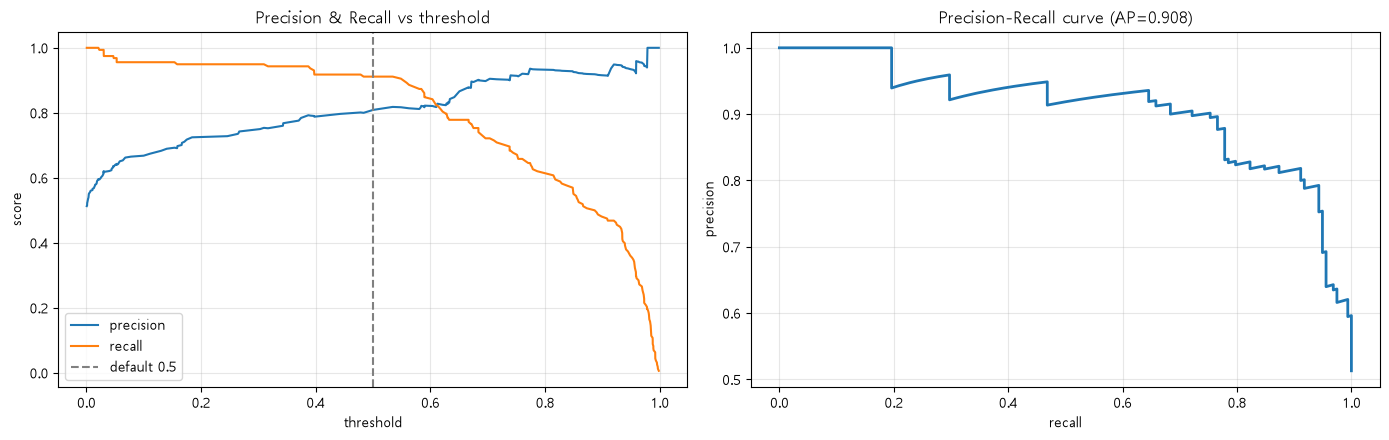

In [ ]:
from sklearn.metrics import precision_recall_curve, roc_curve, auc, average_precision_score

# 모든 임계값에 대한 정밀도·재현율을 한 번에 계산해준다
prec, rec, thr = precision_recall_curve(y_test, prob)

fig, ax = plt.subplots(1, 2, figsize=(14,4.5))
# 왼쪽: 임계값에 따라 두 지표가 서로 반대로 움직이는 모습
ax[0].plot(thr, prec[:-1], label='precision')
ax[0].plot(thr, rec[:-1], label='recall')
ax[0].axvline(0.5, ls='--', color='gray', label='default 0.5')      # 기본 기준선 표시
ax[0].set_xlabel('threshold'); ax[0].set_ylabel('score')
ax[0].set_title('Precision & Recall vs threshold'); ax[0].legend(); ax[0].grid(alpha=0.3)

# 오른쪽: 재현율 대비 정밀도 곡선 (오른쪽 위로 붙을수록 좋은 모델)
ax[1].plot(rec, prec, lw=2)
ax[1].set_xlabel('recall'); ax[1].set_ylabel('precision')
ax[1].set_title(f'Precision-Recall curve (AP={average_precision_score(y_test, prob):.3f})')
ax[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

### 9-2. 목표치를 정하고 임계값 역산하기

실무에서는 **"재현율은 최소 95%는 나와야 한다"** 처럼 목표가 먼저 주어지는 경우가 많다.
→ 그 조건을 만족하는 지점 중 **정밀도가 가장 높은 임계값**을 찾으면 된다.

In [ ]:
from sklearn.metrics import precision_recall_curve, roc_curve, auc, average_precision_score

prec, rec, thr = precision_recall_curve(y_test, prob)

target_recall = 0.95        # "환자를 95% 이상은 찾아내야 한다"는 목표 설정

# Recall이 목표 이상인 지점 중 정밀도가 그나마 가장 높게 하는 Threshold(임계값)을 찾는다
fin = rec[:-1] >= target_recall             # 목표를 만족하는 지점만 True
best_idx = np.argmax(prec[:-1] * fin)       # 조건 밖은 0이 되므로 자동으로 제외된다
best_thr = thr[best_idx]


### target_recall을 넘는 것들 중, precision이 그나마 가장 높게 해주는 threshold 구하기
print('target 재현율: ', target_recall)
print('임계값: ', best_thr)     # 0.5가 아니라 약 0.154로 낮춰야 목표 재현율을 만족한다
print('정밀도: ', prec[best_idx])
print('재현율: ', rec[best_idx])

target 재현율:  0.95
임계값:  0.15373508301974412
정밀도:  0.6926605504587156
재현율:  0.9556962025316456


## 10. ROC Curve & AUC

임계값을 0 → 1 로 쭉 움직이며 **TPR(재현율) vs FPR(오경보율)** 을 그린 곡선.

- **왼쪽 위 모서리에 가까울수록** 좋은 모델
- 대각선 점선 = **찍기(랜덤)** 수준
- **AUC** = 곡선 아래 면적 (0.5 = 랜덤, 1.0 = 완벽)

> 📌 임계값 하나에 얽매이지 않고 **모델 자체의 분별력**을 평가할 수 있다는 게 장점.

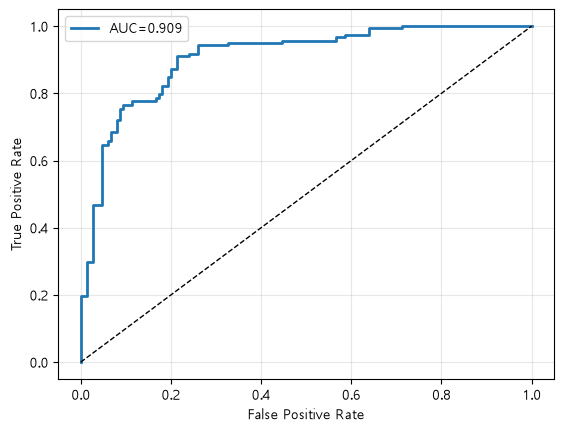

In [ ]:
from sklearn.metrics import roc_curve, auc
# fpr: 오경보율(FP/실제음성), tpr: 재현율(TP/실제양성)
fpr, tpr, _ = roc_curve(y_test, prob)

plt.plot(fpr, tpr, lw=2, label=f'AUC={auc(fpr, tpr):.3f}')      # AUC: 곡선 아래 면적
plt.plot([0,1],[0,1], 'k--',lw=1)       # 대각선 = 랜덤하게 찍었을 때의 성능
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.grid(alpha=0.3)

---
# 🔢 Part 2 · 손글씨 숫자 다중 분류 (`load_digits`)

정답이 **2개(Yes/No)가 아니라 3개 이상**인 문제를 푸는 방법.
(이진 분류 = 질환 있다/없다 ↔ **다중 분류 = 0 ~ 9 중에 무엇인가**)

## 11. 데이터 준비 — 손글씨 숫자(digits) 데이터셋

sklearn 내장 데이터인 `load_digits` 를 사용한다.
**8 × 8 = 64칸**짜리 흑백 이미지이고, 각 칸의 밝기(0~16)가 하나의 Feature 가 된다.

> - `X` : 64개 픽셀 값 (특성)
> - `y` : 그 이미지가 실제로 어떤 숫자인지 (0 ~ 9) → **정답 클래스가 10개**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import load_digits

# sklearn 내장 손글씨 숫자 데이터 (8x8 이미지 1797장)
digits = load_digits()
X, y = digits.data, digits.target   # X: 64개 픽셀값(2차원) / y: 실제 숫자 0~9

# stratify=y : 학습/평가 데이터에 0~9가 같은 비율로 들어가게 나눈다 (클래스 쏠림 방지)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3,
                                                    random_state=8, stratify=y)

# 스케일링 : 특성들의 범위를 맞춰준다 (SVM, LogisticRegression은 스케일에 민감!)
# fit은 반드시 train으로만 → test에는 transform만 적용 (평가 데이터 정보가 새어나가면 안 된다)
sc = StandardScaler().fit(X_train)
X_train_s, X_test_s = sc.transform(X_train), sc.transform(X_test)

### 11-1. 데이터를 눈으로 먼저 확인하기

모델을 돌리기 전에 **내가 다루는 데이터가 어떻게 생겼는지** 직접 본다.
0부터 9까지 한 장씩 뽑아서 그려본다.

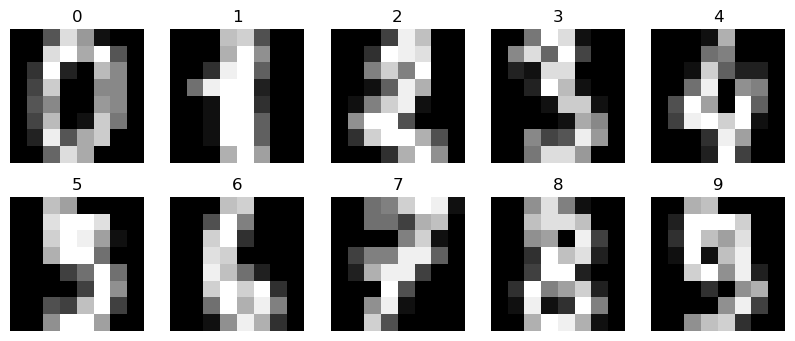

In [ ]:
# 0~9 숫자를 한 장씩 뽑아 2행 5열로 그리기
fig, axes = plt.subplots(2, 5, figsize=(10,4))
for ax, i in zip(axes.ravel(), range(10)):
    ax.imshow(digits.images[y==i][0], cmap='gray')   # 해당 숫자(i)의 첫 번째 이미지
    ax.set_title(i)
    ax.axis('off')      # 눈금 제거 (이미지만 깔끔하게)
plt.show()

## 12. 이진 분류기로 다중 분류하기 — OvR vs OvO

로지스틱 회귀·SVM 같은 모델은 원래 **둘 중 하나(이진)** 를 고르는 모델이다.
그렇다면 클래스가 10개일 땐 어떻게 할까? → **이진 분류기를 여러 개 만들어 투표시킨다.**

| 전략 | 방식 | 분류기 개수 (클래스 n개) | 특징 |
|---|---|---|---|
| **OvR** (One vs Rest) | "0인가 / 0이 아닌가" 를 클래스마다 | **n개** (여기선 10개) | 개수가 적어 **빠르다** |
| **OvO** (One vs One) | "0 vs 1", "0 vs 2" … 모든 쌍 | **n(n−1)/2개** (여기선 45개) | 한 판이 작아 **정확한 편** |

> 💡 실제로는 sklearn 이 알아서 처리해주기 때문에 직접 감쌀 일은 많지 않다.
> 다만 **"내부에서 이렇게 돌아간다"** 는 걸 알아야 학습 시간·성능 차이를 이해할 수 있다.

In [ ]:
# 이진 분류기로 다중 분류 하는 2가지 방법
# OvR(One vs Rest): 0인지 아닌지, 1인지 아닌지,..., 9인지 아닌지 → 분류기 10개
# OvO(One vs One): 0 vs 1, 0 vs 2, ....., 8 vs 9 모든 쌍 → 분류기가 45개

from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.multiclass import OneVsRestClassifier, OneVsOneClassifier

# 같은 SVC를 두 전략으로 각각 감싸서 비교해본다
for name, clf in [('OvR',OneVsRestClassifier(SVC())),
                 ('OvO', OneVsOneClassifier(SVC()))]:
    clf.fit(X_train_s, y_train)
    n_est = len(clf.estimators_)    # 내부에서 실제로 만들어진 이진 분류기의 개수
    # 전략 이름 / 분류기 개수 / 정확도 순으로 출력
    print(f'{name:<28}{n_est:>10}{clf.score(X_test_s, y_test):>10.4f}')

OvR                                 10    0.9759
OvO                                 45    0.9796


## 13. Confusion Matrix — 어떤 숫자끼리 헷갈리는가

정확도(Accuracy) 하나만 보면 **"어디서" 틀렸는지**를 알 수 없다.
혼동 행렬은 **행 = 실제 정답, 열 = 모델의 예측**으로 개수를 세어 보여준다.

> - **대각선** = 맞힌 것 (실제 3을 3이라고 예측)
> - **대각선 밖** = 틀린 것 → 여기가 개선 포인트!

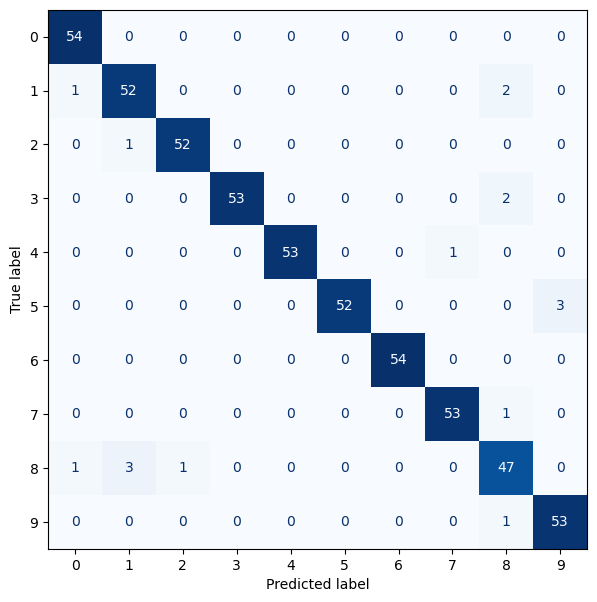

In [ ]:
# sklearn 제공하는 OvsO, OvsR 다중 클래스 분류하는 것도 가능하다

# 0~9 사이에 어떤 숫자를 분류할 때 서로 혼동되는가
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

# max_iter=5000 : 기본값(100)으로는 수렴이 덜 되어 경고가 뜨므로 반복 횟수를 늘려준다
lr = LogisticRegression(max_iter=5000).fit(X_train_s, y_train)
pred = lr.predict(X_test_s)

# 행 = 실제 정답 / 열 = 모델의 예측 → 10 x 10 행렬
cm = confusion_matrix(y_test, pred)

fig, ax = plt.subplots(figsize=(8,7))
# 색이 진할수록 개수가 많다 → 대각선이 진하면 잘 맞히고 있다는 뜻
ConfusionMatrixDisplay(cm, display_labels=range(10)).plot(ax=ax, cmap='Blues', colorbar=False)

### 13-1. 가장 많이 헷갈린 조합 Top 5 뽑아내기

10×10 행렬을 눈으로 훑기보다, **대각선(정답)을 0으로 지운 뒤** 큰 값부터 정렬하면
"어떤 숫자를 어떤 숫자로 착각하는지" 를 바로 뽑아낼 수 있다.

In [ ]:
cm_off = cm.copy()
np.fill_diagonal(cm_off, 0)     # 대각선(=맞힌 것)을 0으로 → 오답만 남긴다

# argsort는 오름차순이므로 -를 붙여 내림차순(많이 틀린 순)으로 정렬
# unravel_index : 1차원 순번을 (행, 열) 좌표로 되돌린다 → (실제값, 예측값)
idx = np.dstack(np.unravel_index(np.argsort(-cm_off.ravel()),cm_off.shape))[0][:5]
for i, j in idx:
    print(f'실제 값 {i} → {j}로 잘못 예측: {cm_off[i,j]}건')

실제 값 5 → 9로 잘못 예측: 3건
실제 값 8 → 1로 잘못 예측: 3건
실제 값 3 → 8로 잘못 예측: 2건
실제 값 1 → 8로 잘못 예측: 2건
실제 값 9 → 8로 잘못 예측: 1건


## 14. 클래스별 성능 — `classification_report`

혼동 행렬을 **숫자 지표로 요약**해준다. 클래스(0~9)마다 따로 계산된다.

| 항목 | 계산 | 해석 |
|---|---|---|
| `precision` | TP / (TP + FP) | **3이라고 예측한 것 중** 진짜 3의 비율 |
| `recall` | TP / (TP + FN) | **진짜 3들 중에서** 3이라고 맞힌 비율 |
| `f1-score` | precision · recall 의 조화평균 | 둘의 균형 |
| `support` | 해당 클래스의 실제 개수 | 표본이 적으면 지표가 흔들린다 |

In [ ]:
# Class 별 성능: 어떤 숫자 분류가 제일 어려운가
# digits=3 : 소수점 셋째 자리까지 표시
print(classification_report(y_test, pred, digits=3))

              precision    recall  f1-score   support

           0      0.964     1.000     0.982        54
           1      0.929     0.945     0.937        55
           2      0.981     0.981     0.981        53
           3      1.000     0.964     0.981        55
           4      1.000     0.981     0.991        54
           5      1.000     0.945     0.972        55
           6      1.000     1.000     1.000        54
           7      0.981     0.981     0.981        54
           8      0.887     0.904     0.895        52
           9      0.946     0.981     0.964        54

    accuracy                          0.969       540
   macro avg      0.969     0.968     0.968       540
weighted avg      0.969     0.969     0.969       540



### 14-1. 요약 지표 — macro · micro · weighted 평균

클래스가 10개면 f1 도 10개다. 이걸 **하나의 숫자로 요약**하는 방법이 3가지 있다.

| 평균 방식 | 계산 방법 | 언제 쓰나 |
|---|---|---|
| **macro** | 클래스별 F1 을 **단순 평균** | 데이터가 적은 클래스도 **똑같이 중요**할 때 |
| **micro** | 전체 TP/FP/FN 을 **합쳐서** 한 번에 계산 | 샘플이 많은 클래스 위주로 보고 싶을 때 |
| **weighted** | 클래스 **크기로 가중 평균** | 클래스 불균형을 그대로 반영하고 싶을 때 |

> 📌 이번 digits 데이터는 클래스가 거의 균등해서 세 값이 비슷하게 나온다.
> **불균형 데이터라면 세 값이 크게 벌어지고, 그때 어떤 걸 보느냐가 중요해진다.**

In [ ]:
# macro: 클래스 별로 F1을 단순 평균 (얼마 없는 클래스도 동등하고 중요하게 생각한다.)
# micro: 전체 TP/FP/FN을 합쳐 계산 (샘플이 많은 클래스에 좌우된다.)
# weighted: 클래스를 크기로 가중 평균 (클래스별 데이터의 불균형을 반영.)

from sklearn.metrics import f1_score

for avg in ['macro', 'micro', 'weighted']:
    print(f'{avg:<10} F1 = {f1_score(y_test, pred, average=avg):.4f}')

macro      F1 = 0.9684
micro      F1 = 0.9685
weighted   F1 = 0.9687


## 15. 오답 데이터 직접 확인하기

지표는 **얼마나** 틀렸는지 알려줄 뿐, **왜** 틀렸는지는 알려주지 않는다.
틀린 이미지를 직접 보면 "사람이 봐도 헷갈릴 만하다" 는 걸 확인할 수 있다.
(예: 흐릿한 8과 1, 획이 이어진 5와 9)

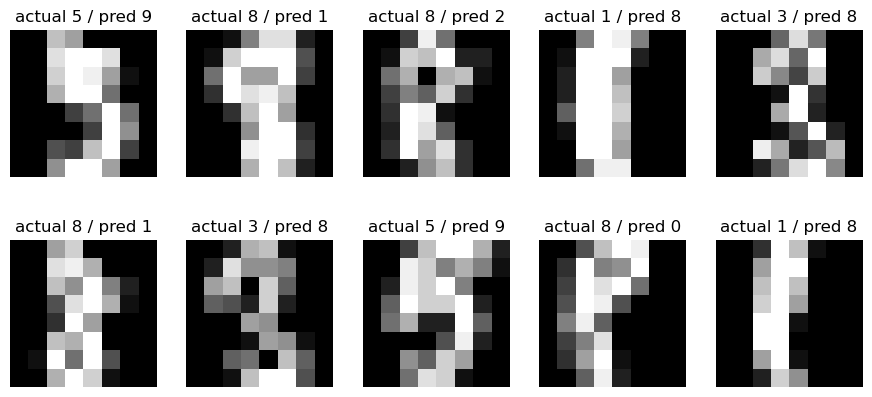

In [ ]:
# 어떤 데이터에 대해서 틀렸는지, 실제 그 데이터 살피기
wrong = np.where(pred != y_test)[0][:10]    # 예측 ≠ 정답 인 데이터의 위치, 앞에서 10개만

fig, axes = plt.subplots(2,5,figsize=(11,5))
for ax, w in zip(axes.ravel(), wrong):
    ax.imshow(X_test[w].reshape(8,8), cmap='gray')   # 1차원 64개 → 다시 8x8 이미지로
    ax.set_title(f'actual {y_test[w]} / pred {pred[w]}')     # 정답 / 예측 함께 표기
    ax.axis('off')
plt.show()

---
## ✅ 오늘 배운 내용 정리

| 구분 | 개념 / 도구 | 핵심 요약 |
|---|---|---|
| 전처리 | `dropna` · `pd.cut` | 결측치 제거, 연속형을 구간(범주형)으로 묶어 비교 |
| 인코딩 | `map` · `pd.get_dummies` | 문자형 → 숫자. 순서 없는 값은 **One-Hot** |
| 분류 모델 | `LogisticRegression` | 선형식 → Sigmoid → **확률**로 분류 (`C`, `max_iter`) |
| 분류 모델 | `LinearSVC` | 마진이 가장 넓은 경계선. `C` ↑ = 복잡 = 과대적합 위험 |
| 검증 | `cross_val_score` | 여러 겹으로 나눠 평가 → **일반화 성능** 확인 |
| 지표 | `classification_report` | precision · recall · f1 · support |
| 지표 | **Threshold 조정** | 0.5는 고정값이 아니다 → **재현율 ↔ 정밀도 맞교환** |
| 곡선 | PR curve · ROC curve (AUC) | 임계값 전체를 훑어 **모델 자체의 분별력** 평가 |
| 다중 분류 | `OneVsRest` · `OneVsOne` | 분류기 **n개** vs **n(n−1)/2개** |
| 진단 | `confusion_matrix` | 행=실제, 열=예측. **대각선 밖**이 개선 포인트 |
| 지표 요약 | `f1_score(average=...)` | **macro**(동등) · **micro**(전체합) · **weighted**(크기 가중) |

**기억할 포인트**
1. **정확도(Accuracy) 하나만 보면 속는다.** 클래스가 불균형하면 특히 그렇다.
2. **문제의 성격에 따라 볼 지표가 달라진다.**
   - 놓치면 위험 → **Recall** (심장질환·암 진단)
   - 잘못 잡으면 위험 → **Precision** (스팸 메일)
3. **임계값 0.5는 절대 기준이 아니다.** 모델을 다시 학습시키지 않고도 기준선만 옮겨
   목적에 맞게(예: 재현율 95% 이상) 조정할 수 있다.
4. 다중 분류 전략(OvR·OvO)은 **sklearn 이 알아서 처리해준다** — 원리만 알아두면 된다.
5. Confusion Matrix 로 **어떤 클래스끼리 헷갈리는지** 확인하고, **틀린 데이터를 직접 본다.**
6. 스케일링은 **train 으로만 `fit`**, test 에는 `transform` 만! (데이터 누수 방지)
   `train_test_split(stratify=y)` 로 클래스 비율도 유지한다.